# ***Assignment 11: Decision Tree Classification (heart_disease.xlsx)***

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

***Task 1 & 2: Data Loading & Exploratory Data Analysis***

--- Dataset Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB
None

--- Summary Statistics ---
              age    trestbps        chol      thalch     oldpeak         num
count  908.000000  908.000000  908.000000  908.000000  846.000000  908.000000
mean    53.791850  133.4

/tmp/ipykernel_2948/3154612298.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df_clean, palette="Set2")


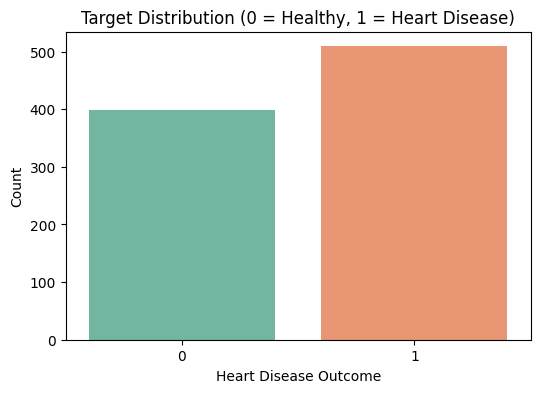

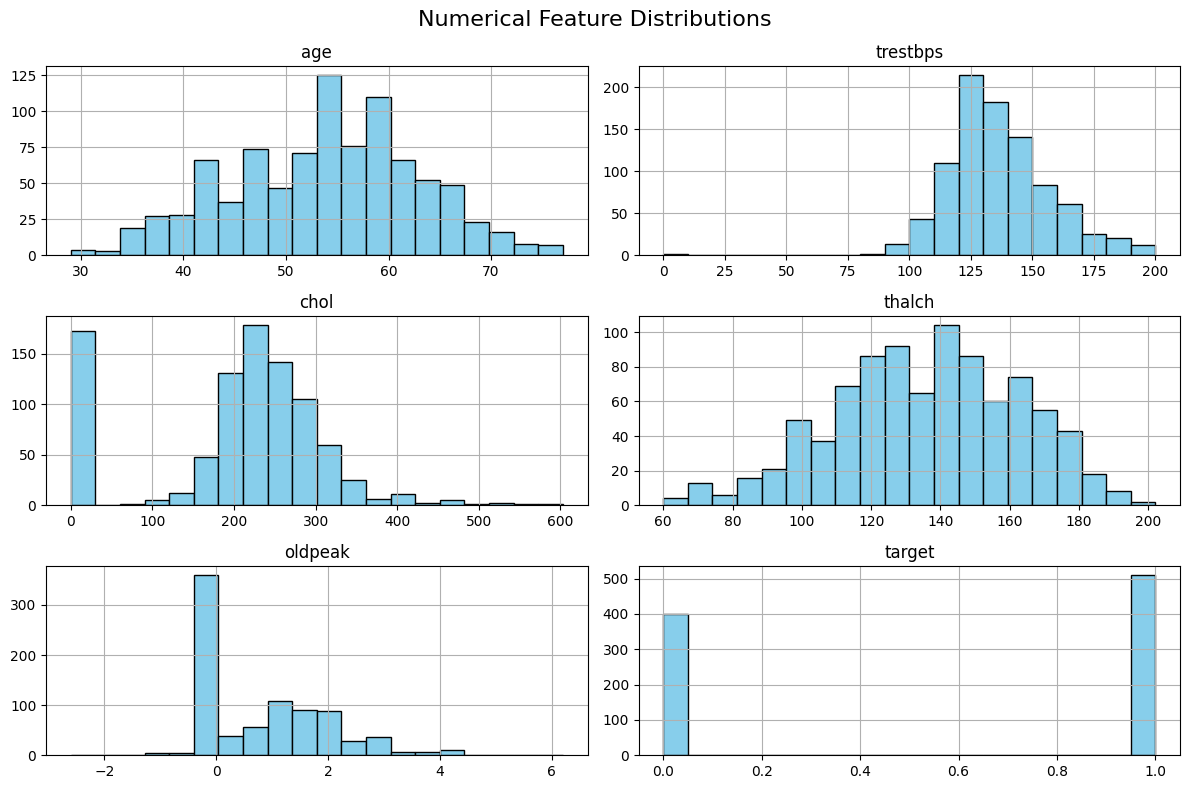

In [27]:
df_heart = pd.read_excel("/content/heart_disease.xlsx", sheet_name="Heart_disease")

print("--- Dataset Overview ---")
print(df_heart.info())

print("\n--- Summary Statistics ---")
print(df_heart.describe())

# Check missing values
print("\nMissing Values Count:\n", df_heart.isnull().sum())

# Create binary target variable 'target' (1 = Heart Disease, 0 = No Disease)
df_heart["target"] = (df_heart["num"] > 0).astype(int)
df_clean = df_heart.drop(columns=["num"]).copy()

# Visualizations: Target Class Distribution & Feature Histograms
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df_clean, palette="Set2")
plt.title("Target Distribution (0 = Healthy, 1 = Heart Disease)")
plt.xlabel("Heart Disease Outcome")
plt.ylabel("Count")
plt.show()

num_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[num_cols].hist(
    figsize=(12, 8), bins=20, color="skyblue", edgecolor="black"
)
plt.suptitle("Numerical Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

**Task 3: Data Preprocessing & Feature Engineering**

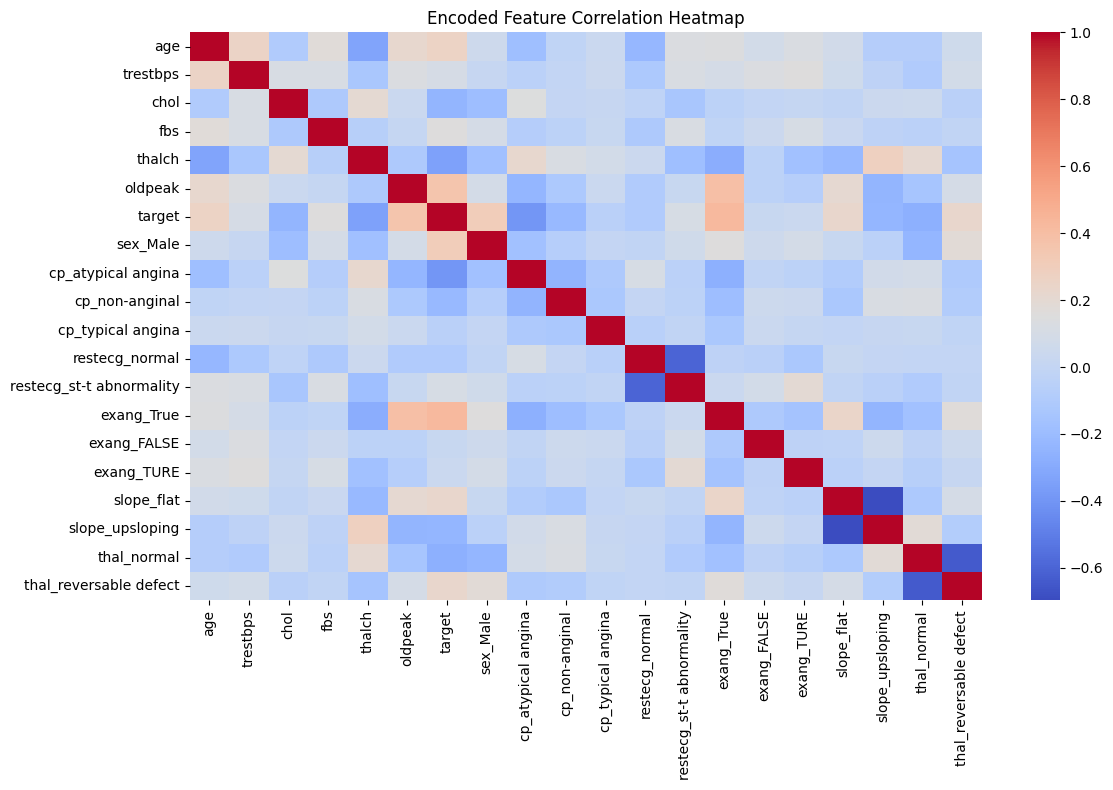

In [28]:
df_clean["oldpeak"] = df_clean["oldpeak"].fillna(df_clean["oldpeak"].median())

# One-Hot Encoding for categorical variables
df_encoded = pd.get_dummies(df_clean, drop_first=True)

X = df_encoded.drop(columns=["target"])
y = df_encoded["target"]

# Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=False, cmap="coolwarm")
plt.title("Encoded Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

***Task 4: Decision Tree Classification***

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Baseline Decision Tree Model[cite: 15]
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

y_pred_base = dt_base.predict(X_test)
y_prob_base = dt_base.predict_proba(X_test)[:, 1]

print("\n--- Baseline Decision Tree Performance ---")
print("Accuracy :", accuracy_score(y_test, y_pred_base))
print("Precision:", precision_score(y_test, y_pred_base))
print("Recall   :", recall_score(y_test, y_pred_base))
print("F1-Score :", f1_score(y_test, y_pred_base))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_base))


--- Baseline Decision Tree Performance ---
Accuracy : 0.7032967032967034
Precision: 0.74
Recall   : 0.7254901960784313
F1-Score : 0.7326732673267327
ROC-AUC  : 0.7002450980392158


***Task 5: Hyperparameter Tuning***

In [30]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_
print("\n--- Best Decision Tree Hyperparameters ---")
print(grid_search.best_params_)


--- Best Decision Tree Hyperparameters ---
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}


***Task 6: Model Evaluation and Analysis***


--- Tuned Decision Tree Performance ---
Accuracy : 0.7472527472527473
Precision: 0.7916666666666666
Recall   : 0.7450980392156863
F1-Score : 0.7676767676767676
ROC-AUC  : 0.7949142156862745


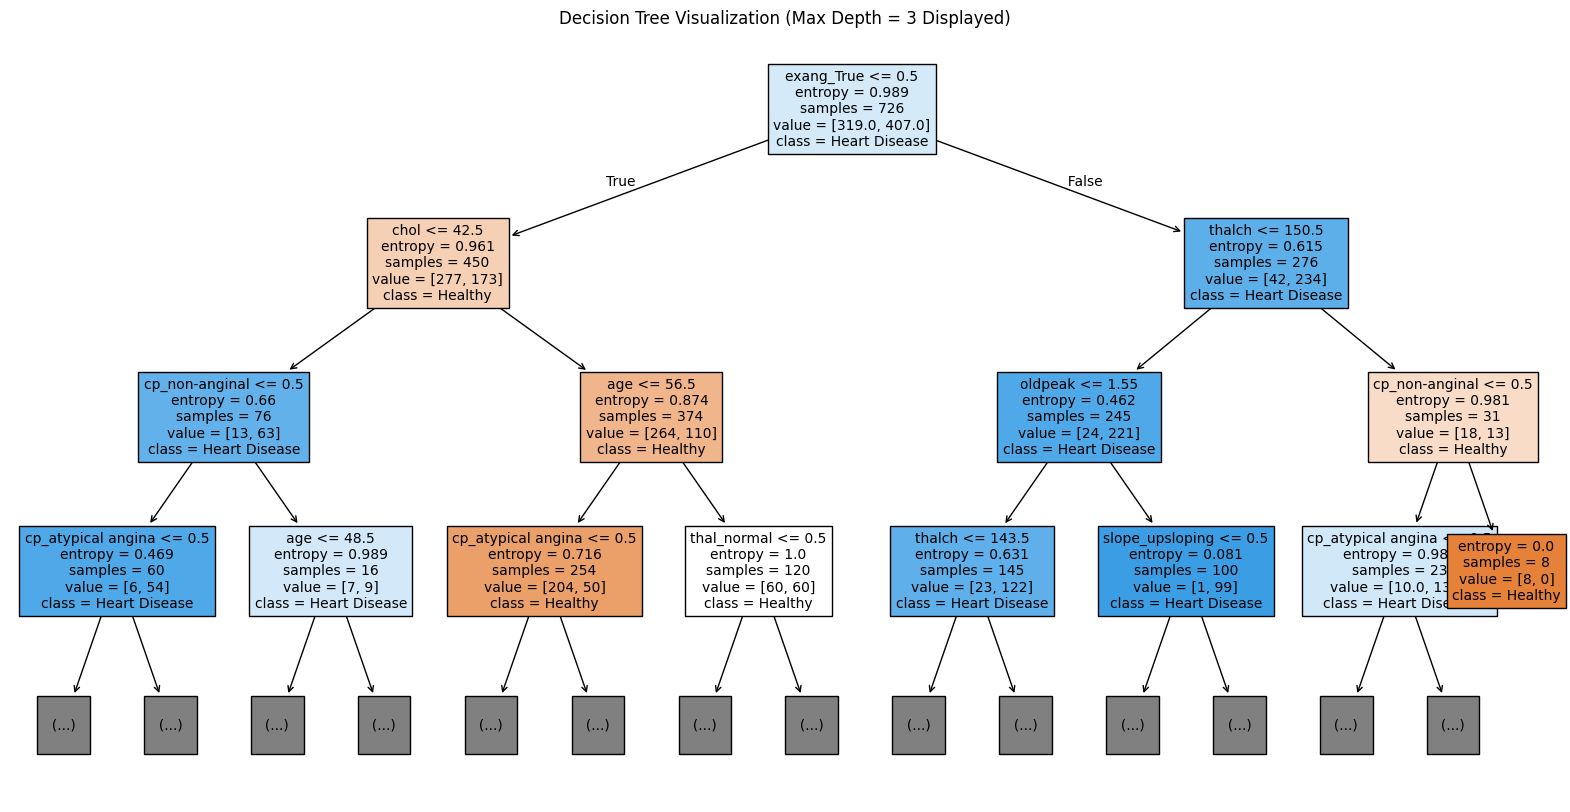

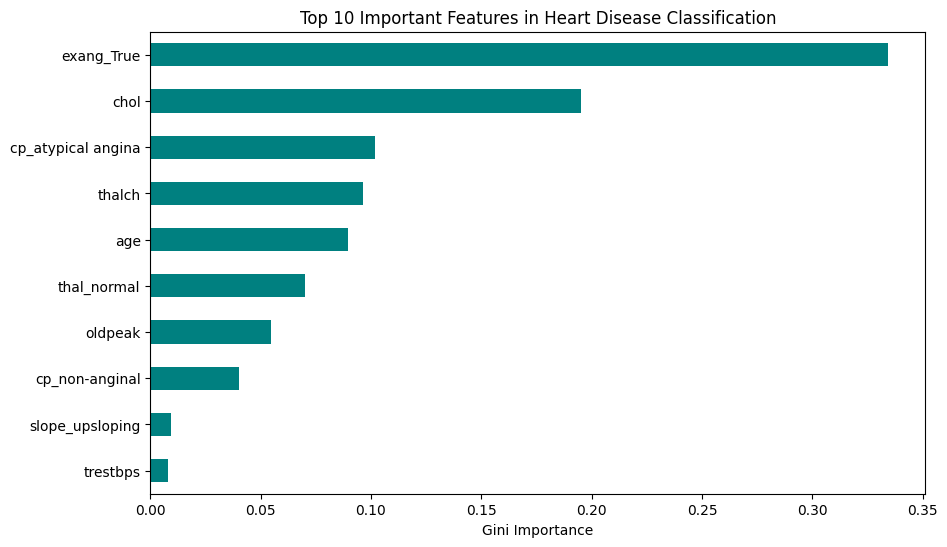

In [31]:
y_pred_opt = best_dt.predict(X_test)
y_prob_opt = best_dt.predict_proba(X_test)[:, 1]

print("\n--- Tuned Decision Tree Performance ---")
print("Accuracy :", accuracy_score(y_test, y_pred_opt))
print("Precision:", precision_score(y_test, y_pred_opt))
print("Recall   :", recall_score(y_test, y_pred_opt))
print("F1-Score :", f1_score(y_test, y_pred_opt))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_opt))

# Visualize the Learned Decision Tree Structure[cite: 15]
plt.figure(figsize=(20, 10))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=["Healthy", "Heart Disease"],
    filled=True,
    max_depth=3,
    fontsize=10,
)
plt.title("Decision Tree Visualization (Max Depth = 3 Displayed)")
plt.show()

# Feature Importance Analysis[cite: 15]
feature_importances = pd.Series(
    best_dt.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importances.head(10).plot(kind="barh", color="teal")
plt.title("Top 10 Important Features in Heart Disease Classification")
plt.gca().invert_yaxis()
plt.xlabel("Gini Importance")
plt.show()